In [2]:
!pip3 uninstall torch
!pip3 install "torch==2.5.1" "torchvision==0.20.1" "torchaudio==2.5.1"
!pip3 install "tensorboardX"
!pip3 install vnstock
!pip3 install pytorch-forecasting
!pip3 install pytorch_optimizer

Found existing installation: torch 2.5.1
Uninstalling torch-2.5.1:
  Would remove:
    /Library/Frameworks/Python.framework/Versions/3.12/bin/convert-caffe2-to-onnx
    /Library/Frameworks/Python.framework/Versions/3.12/bin/convert-onnx-to-caffe2
    /Library/Frameworks/Python.framework/Versions/3.12/bin/torchfrtrace
    /Library/Frameworks/Python.framework/Versions/3.12/bin/torchrun
    /Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/functorch/*
    /Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch-2.5.1.dist-info/*
    /Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/*
    /Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torchgen/*
Proceed (Y/n)? ^C
ERROR: Operation cancelled by user

[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip3 install --upgrade pip


In [63]:
!pip3 install optuna statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 26.7 MB/s eta 0:00:001m23.9 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 27.3 MB/s eta 0:00:00

[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip3 install --upgrade pip


In [31]:
import os
import warnings

warnings.filterwarnings("ignore")  # avoid printing out absolute p Yaths
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
from datetime import datetime
import numpy.testing as npt
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor
from lightning.pytorch.loggers import TensorBoardLogger

import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)
import torch

from pytorch_forecasting import Baseline, TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer, MultiNormalizer, EncoderNormalizer, TorchNormalizer
from pytorch_forecasting.data.encoders import NaNLabelEncoder
from pytorch_forecasting.metrics import MAE, SMAPE, PoissonLoss, QuantileLoss,CrossEntropy, MultiLoss
from pytorch_forecasting.models.temporal_fusion_transformer.tuning import optimize_hyperparameters
from lightning.pytorch.tuner import Tuner
import torch
from pytorch_forecasting.data.encoders import GroupNormalizer, NaNLabelEncoder
from pytorch_optimizer import Ranger, RMSprop , Adam
from types import MethodType
device = "mps" if torch.cuda.is_available() else "cpu"
import os
from vnstock import * #import all functions

In [32]:
def convert_data_type(df, time_cols=[], float_cols = [], cat_cols = []):
    for col in time_cols:
        df[col] = pd.to_datetime(df[col], format = '%Y-%m-%d')
    for col in float_cols:
        df[col] = df[col].astype(float)
    for col in cat_cols:
        df[col] = df[col].astype('category')
    return df

In [33]:
time_cols = ['time']
float_cols = ['open', 'high', 'low', 'close', 'volume']
cat_cols = ['symbol']

In [34]:
from vnstock import Listing
company_list = Listing(source='vci')
cp_list = company_list.symbols_by_group('VN30')


In [46]:
import pandas as pd
from vnstock import Quote
from tqdm import tqdm
df = pd.DataFrame()
start_date = '2025-12-19'
end_date = '2025-12-28'
for company in tqdm(cp_list,desc="extract source"):
    try: 
        quote = Quote(symbol=company, source='vci')
        data = quote.history(start=start_date, end=end_date, interval='1m')
        data['symbol'] = company
        df = pd.concat([df, data], axis=0)
    except:
        continue

extract source: 100%|███████████████████████████████████████████████| 30/30 [00:33<00:00,  1.13s/it]


In [47]:
df.describe()

,time,open,high,low,close,volume
count,81930,81930.000000,81930.000000,81930.000000,81930.000000,8.193000e+04
mean,2025-12-18 17:40:21.126327552,53.248787,53.289066,53.203508,53.248100,4.583446e+04
min,2025-11-24 11:07:00,15.650000,15.700000,15.650000,15.650000,1.000000e+02
25%,2025-12-15 10:43:00,26.500000,26.500000,26.500000,26.500000,3.000000e+03
50%,2025-12-18 13:07:00,36.900000,36.950000,36.850000,36.900000,1.140000e+04
75%,2025-12-23 13:49:00,65.400000,65.400000,65.400000,65.400000,3.480000e+04
max,2025-12-26 14:45:00,212.900000,212.900000,212.900000,212.900000,1.369120e+07
std,NaN,40.328805,40.358008,40.297820,40.328677,1.848853e+05


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 81930 entries, 0 to 2730
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   time    81930 non-null  datetime64[ns]
 1   open    81930 non-null  float64       
 2   high    81930 non-null  float64       
 3   low     81930 non-null  float64       
 4   close   81930 non-null  float64       
 5   volume  81930 non-null  int64         
 6   symbol  81930 non-null  object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 5.0+ MB


In [49]:
df['symbol'].value_counts()

symbol
ACB    2731
BCM    2731
VPB    2731
VNM    2731
VJC    2731
VIC    2731
VIB    2731
VHM    2731
VCB    2731
TPB    2731
TCB    2731
STB    2731
SSI    2731
SSB    2731
SHB    2731
SAB    2731
PLX    2731
MWG    2731
MSN    2731
MBB    2731
LPB    2731
HPG    2731
HDB    2731
GVR    2731
GAS    2731
FPT    2731
DGC    2731
CTG    2731
BID    2731
VRE    2731
Name: count, dtype: int64

# CREATE DATASET

In [50]:
df = df.set_index('time', drop=True).reset_index() 

In [51]:
# Group by 'stock' and sort values by 'time'
df = df.groupby('symbol').apply(lambda x: x.sort_values('time')).reset_index(drop=True)

# Create 'time_idx' column from 0 to the length of each stock
df['time_idx'] = df.groupby('symbol').cumcount()

In [52]:
df.head()

,time,open,high,low,close,volume,symbol,time_idx
0,2025-12-10 11:24:00,24.15,24.20,24.15,24.20,4300,ACB,0
1,2025-12-10 11:25:00,24.20,24.20,24.15,24.15,5200,ACB,1
2,2025-12-10 11:26:00,24.15,24.15,24.15,24.15,93800,ACB,2
3,2025-12-10 11:27:00,24.15,24.20,24.15,24.20,8100,ACB,3
4,2025-12-10 11:29:00,24.20,24.20,24.20,24.20,6000,ACB,4


In [55]:
TRAIN_PERIOD_END = "2025-12-24"
VAL_PERIOD_END = "2025-12-25"
df_train = df[df["time"] < TRAIN_PERIOD_END]
df_val = df[(df["time"] >= TRAIN_PERIOD_END) & (df["time"] < VAL_PERIOD_END)]
df_test = df[df["time"] >= VAL_PERIOD_END]
print(f"Total train rows: {len(df_train)}, Total validation rows: {len(df_val)}, Total test rows: {len(df_test)}")

Total train rows: 62676, Total validation rows: 6439, Total test rows: 12815


In [56]:
max_prediction_length = 10
max_encoder_length = 10


In [57]:
training = TimeSeriesDataSet(
    df_train,
    time_idx="time_idx",
    target="close",
    group_ids=["symbol"],
    min_encoder_length=max_encoder_length // 2,  # keep encoder length long (as it is in the validation set)
    max_encoder_length=max_encoder_length,
    min_prediction_length=1,
    max_prediction_length=max_prediction_length,
    static_categoricals=["symbol"],
    time_varying_known_reals=["time_idx"],
    time_varying_unknown_categoricals=[],
    time_varying_unknown_reals=[
        'open', 'high', 'low', 'close', 'volume',
    ],
    target_normalizer=GroupNormalizer(
        groups=["symbol"], transformation="softplus"
    ), 
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=False,
    allow_missing_timesteps=False,
    randomize_length = True,
)

In [58]:
batch_size = 48
train_dataloader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
validation = TimeSeriesDataSet.from_dataset(training, df_val, predict=True, stop_randomization=True)
val_dataloader = validation.to_dataloader(train=False, batch_size=batch_size * 10, num_workers=0)

In [59]:
parameters = training.get_parameters
print(parameters)

<bound method TimeSeriesDataSet.get_parameters of TimeSeriesDataSet[length=62946](
	time_idx='time_idx',
	target='close',
	group_ids=['symbol'],
	weight=None,
	max_encoder_length=10,
	min_encoder_length=5,
	min_prediction_idx=np.int64(0),
	min_prediction_length=1,
	max_prediction_length=10,
	static_categoricals=['symbol'],
	static_reals=None,
	time_varying_known_categoricals=None,
	time_varying_known_reals=['time_idx'],
	time_varying_unknown_categoricals=[],
	time_varying_unknown_reals=['open', 'high', 'low', 'close', 'volume'],
	variable_groups=None,
	constant_fill_strategy=None,
	allow_missing_timesteps=False,
	lags=None,
	add_relative_time_idx=True,
	add_target_scales=True,
	add_encoder_length=False,
	target_normalizer=GroupNormalizer(
	method='standard',
	groups=['symbol'],
	center=True,
	scale_by_group=False,
	transformation='softplus',
	method_kwargs={}
),
	categorical_encoders={'__group_id__symbol': NaNLabelEncoder(add_nan=False, warn=True), 'symbol': NaNLabelEncoder(add_nan=Fal

In [22]:
# # find optimal learning rate

# # configure network and trainer
# pl.seed_everything(44)
# trainer = pl.Trainer(
#     accelerator=device,
#     gradient_clip_val=0.1,
# )
# tft = TemporalFusionTransformer.from_dataset(
#     training,
#     # not meaningful for finding the learning rate but otherwise very important
#     # learning_rate=0.03,
#     hidden_size=128,  # most important hyperparameter apart from learning rate
#     lstm_layers=2,
#     attention_head_size=4,# number of attention heads. Set to up to 4 for large datasets
#     dropout=0.1,  # between 0.1 and 0.3 are good values
#     hidden_continuous_size=4,  # set to <= hidden_size
#     loss=QuantileLoss(),
#     # reduce learning rate if no improvement in validation loss after x epochs
#     reduce_on_plateau_patience=100,
# )

# def configure_optimizers(self):
#     return Ranger(self.parameters())

# tft.configure_optimizers = MethodType(configure_optimizers, tft)

# print(f"Number of parameters in network: {tft.size()/1e3:.1f}k")


Seed set to 44
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores


Number of parameters in network: 1108.6k


In [58]:

# res = Tuner(trainer).lr_find(
#     tft,
#     train_dataloaders=train_dataloader,
#     val_dataloaders=val_dataloader,
# )

# print(f"suggested learning rate: {res.suggestion()}")
# fig = res.plot(show=True, suggest=True)
# fig.show()

In [60]:
# configure network and trainer
early_stop_callback = EarlyStopping(monitor="val_loss", min_delta=1e-4,
                                    patience=10, verbose=False, mode="min")
lr_logger = LearningRateMonitor()  # log the learning rate
logger = TensorBoardLogger("lightning_logs")  # logging results to a tensorboard

trainer = pl.Trainer(
    max_epochs=15,
    accelerator='mps',
    enable_model_summary=True,
    gradient_clip_val=0.1,
    limit_train_batches=50, 
    callbacks=[lr_logger, early_stop_callback],
    logger=logger,
)

tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.03,
    hidden_size=16, 
    lstm_layers=2,
    attention_head_size=4,
    dropout=0.2,  
    hidden_continuous_size=4, 
    loss=QuantileLoss([0.3, 0.5, 0.7]),
    reduce_on_plateau_patience=100,
)

def configure_optimizers(self):
    return Ranger(self.parameters())

tft.configure_optimizers = MethodType(configure_optimizers, tft)

print(f"Number of parameters in network: {tft.size()/1e3:.1f}k")

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores


Number of parameters in network: 22.4k


In [61]:
# fit network
trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)


   | Name                               | Type                            | Params | Mode  | FLOPs
--------------------------------------------------------------------------------------------------------
0  | loss                               | QuantileLoss                    | 0      | train | 0    
1  | logging_metrics                    | ModuleList                      | 0      | train | 0    
2  | input_embeddings                   | MultiEmbedding                  | 330    | train | 0    
3  | prescalers                         | ModuleDict                      | 72     | train | 0    
4  | static_variable_selection          | VariableSelectionNetwork        | 735    | train | 0    
5  | encoder_variable_selection         | VariableSelectionNetwork        | 2.5 K  | train | 0    
6  | decoder_variable_selection         | VariableSelectionNetwork        | 654    | train | 0    
7  | static_context_variable_selection  | GatedResidualNetwork            | 1.1 K  | train | 0    
8  

Sanity Checking: |                                                            | 0/? [00:00<?, ?it/s]

Training: |                                                                   | 0/? [00:00<?, ?it/s]

Validation: |                                                                 | 0/? [00:00<?, ?it/s]

Validation: |                                                                 | 0/? [00:00<?, ?it/s]

...

Validation: |                                                                 | 0/? [00:00<?, ?it/s]

Validation: |                                                                 | 0/? [00:00<?, ?it/s]

Validation: |                                                                 | 0/? [00:00<?, ?it/s]

Validation: |                                                                 | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=15` reached.


In [65]:
# import pickle

# from pytorch_forecasting.models.temporal_fusion_transformer.tuning import optimize_hyperparameters

# # create study
# study = optimize_hyperparameters(
#     train_dataloader,
#     val_dataloader,
#     model_path="optuna_test",
#     n_trials=200,
#     max_epochs=15,
#     gradient_clip_val_range=(0.01, 1.0),
#     hidden_size_range=(8, 128),
#     hidden_continuous_size_range=(8, 128),
#     attention_head_size_range=(1, 4),
#     learning_rate_range=(0.001, 0.1),
#     dropout_range=(0.1, 0.3),
#     trainer_kwargs=dict(limit_train_batches=30),
#     reduce_on_plateau_patience=4,
#     use_learning_rate_finder=False,  # use Optuna to find ideal learning rate or use in-built learning rate finder
# )

# # save study results - also we can resume tuning at a later point in time
# with open("test_study.pkl", "wb") as fout:
#     pickle.dump(study, fout)

# # show best hyperparameters
# print(study.best_trial.params)

In [67]:
best_model_path = trainer.checkpoint_callback.best_model_path
best_tft = TemporalFusionTransformer.load_from_checkpoint(best_model_path)
print(best_model_path)

lightning_logs/lightning_logs/version_8/checkpoints/epoch=14-step=750.ckpt


In [68]:
predictions = best_tft.predict(
    val_dataloader, return_y=True, trainer_kwargs=dict(accelerator="cpu")
)
MAE()(predictions.output, predictions.y)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores


tensor(1.8584)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores


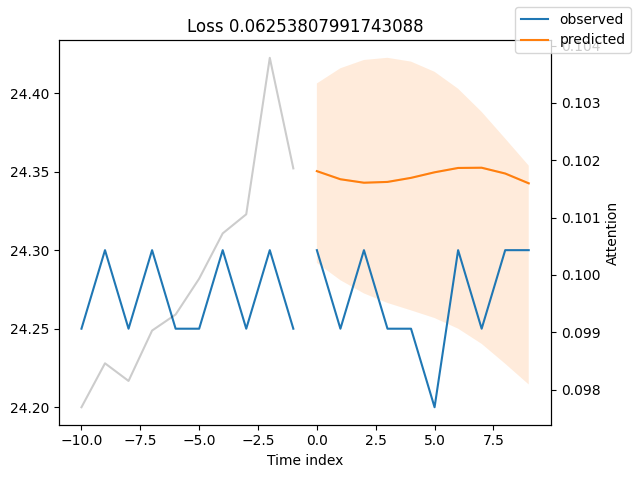

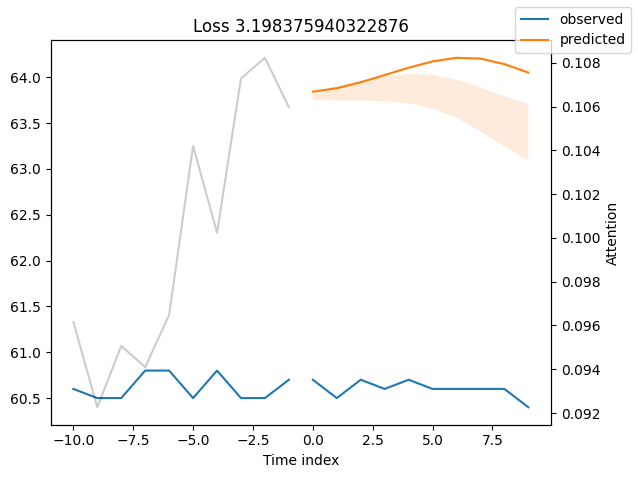

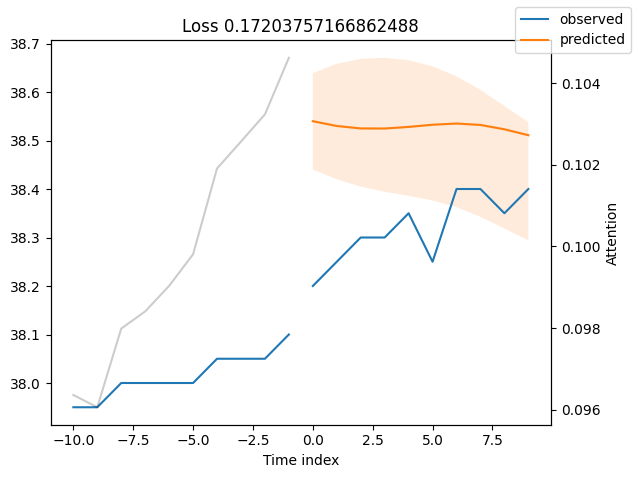

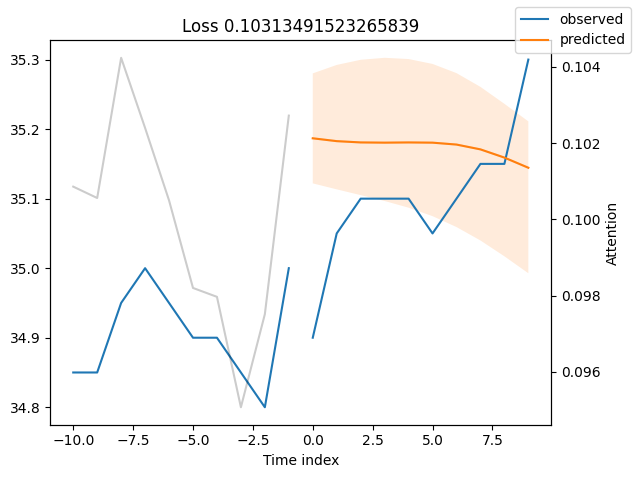

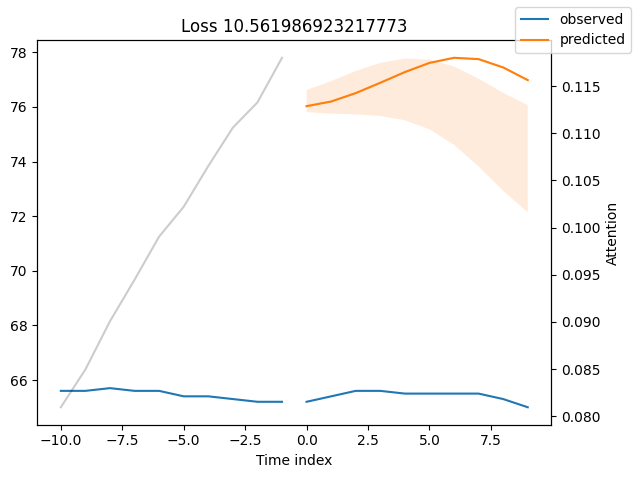

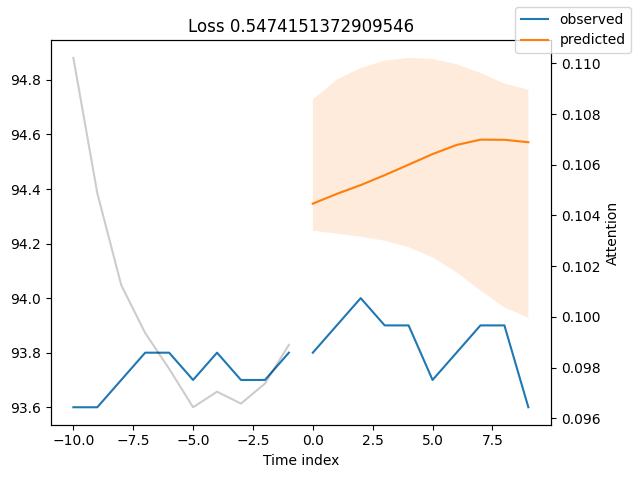

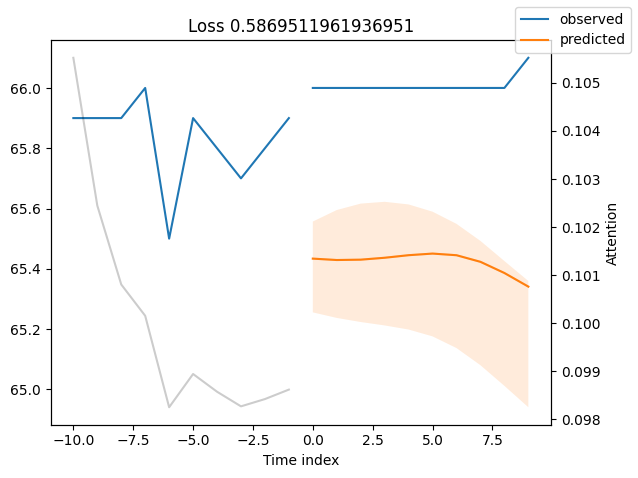

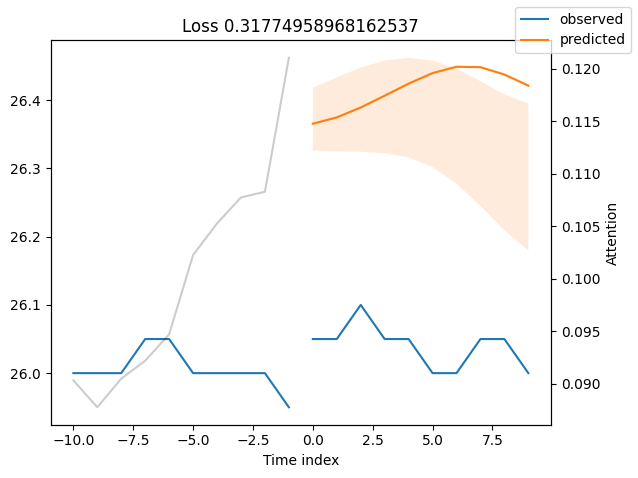

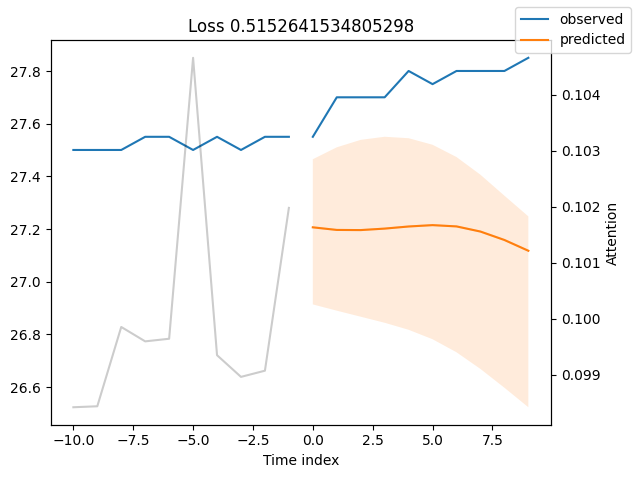

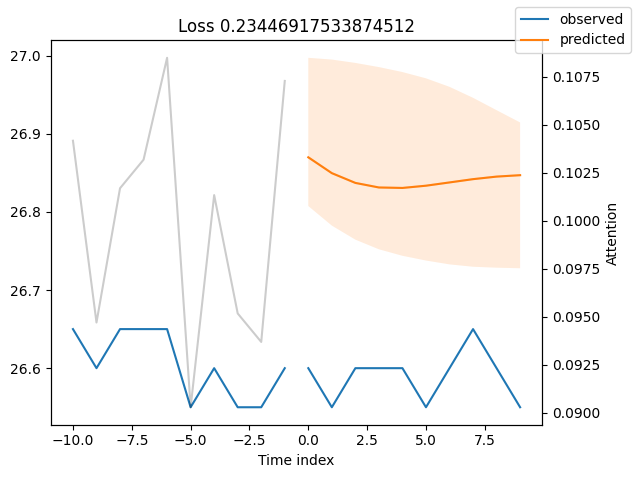

In [69]:
# raw predictions are a dictionary from which all kind of information including quantiles can be extracted
raw_predictions = best_tft.predict(val_dataloader, mode="raw", return_x=True)
for idx in range(10):  # plot 10 examples
    best_tft.plot_prediction(raw_predictions.x, raw_predictions.output, idx=idx, add_loss_to_title=True)

## Worst performers

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores


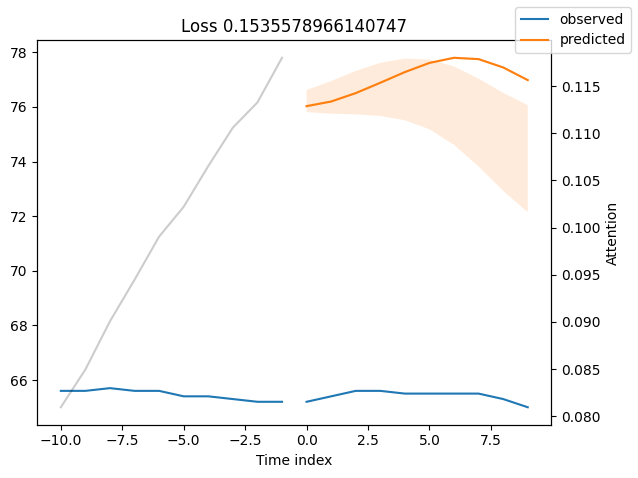

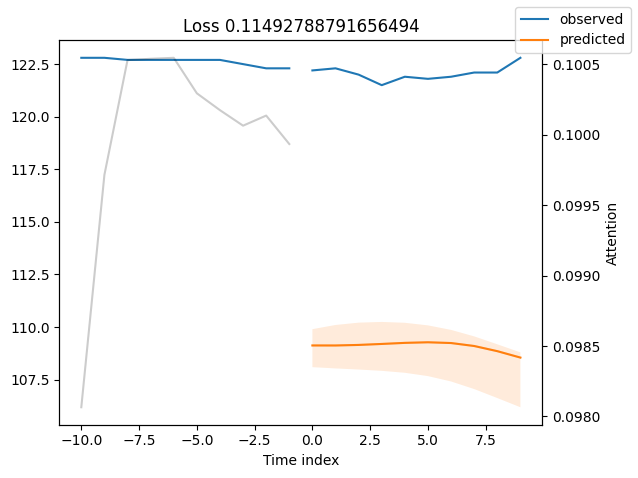

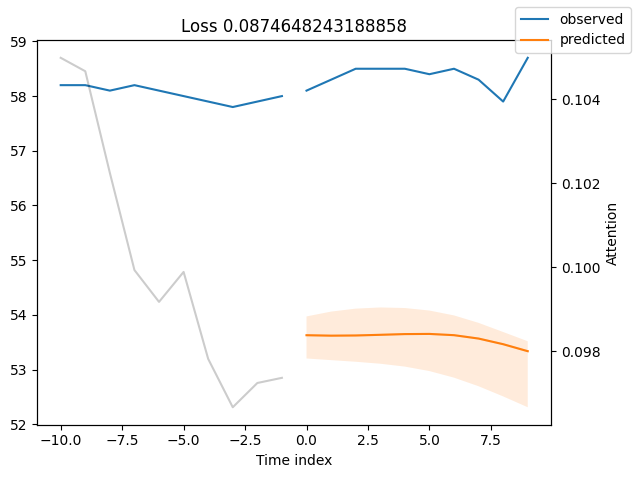

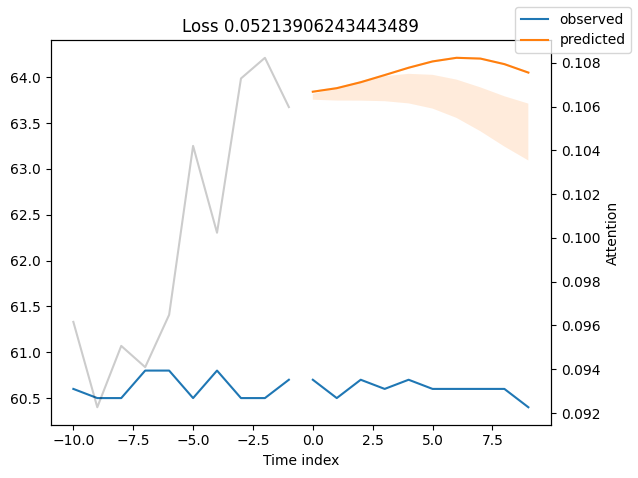

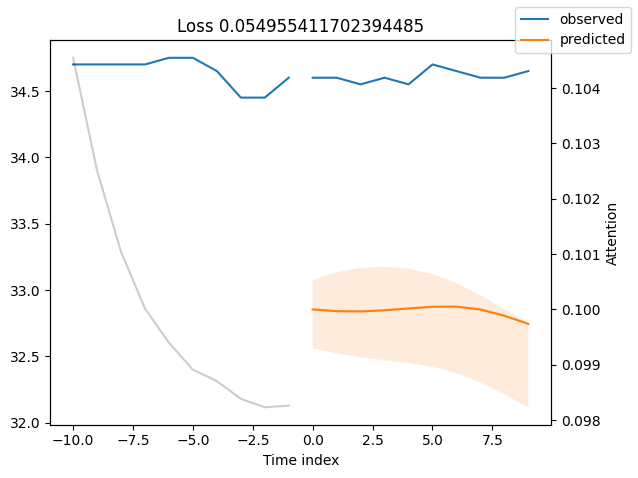

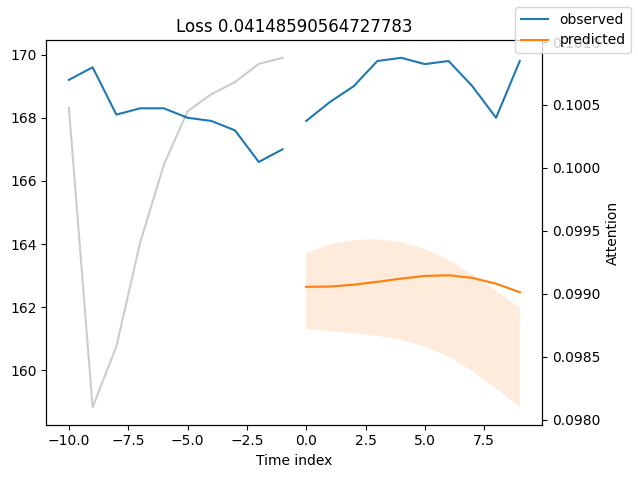

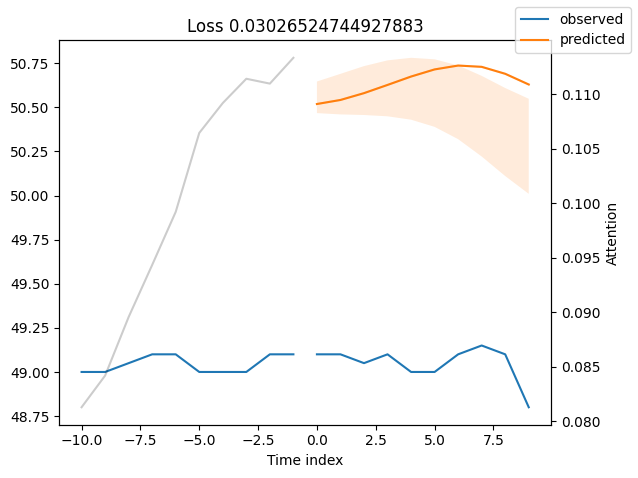

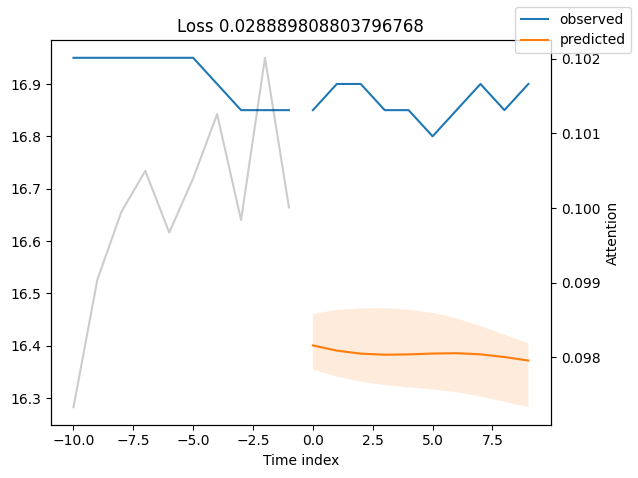

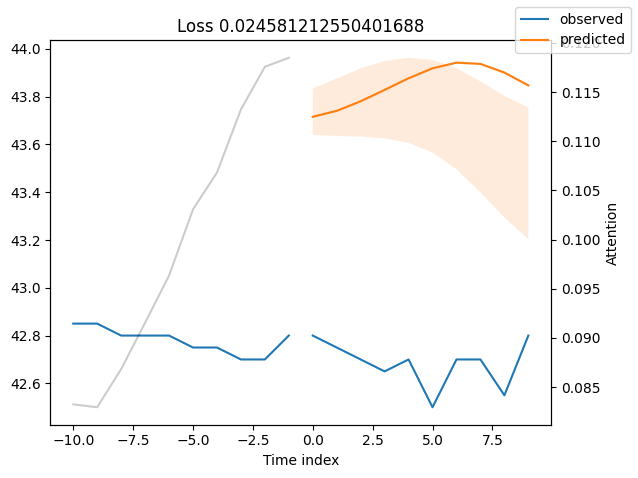

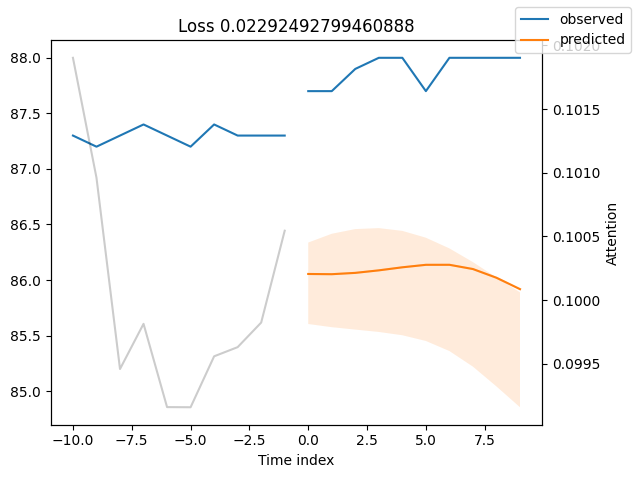

In [75]:
predictions = best_tft.predict(
    val_dataloader, return_y=True, trainer_kwargs=dict(accelerator="cpu")
)
mean_losses = SMAPE(reduction="none").to('cpu').loss(predictions.output, predictions.y[0]).mean(1)
indices = mean_losses.argsort(descending=True)  # sort losses
for idx in range(10):  # plot 10 examples
    best_tft.plot_prediction(
        raw_predictions.x,
        raw_predictions.output,
        idx=indices[idx],
        add_loss_to_title=SMAPE(quantiles=best_tft.loss.quantiles),
    )

## Test

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores


{'close_center': <Figure size 1000x500 with 2 Axes>,
 'close_scale': <Figure size 1000x500 with 2 Axes>,
 'time_idx': <Figure size 1000x500 with 2 Axes>,
 'relative_time_idx': <Figure size 1000x500 with 2 Axes>,
 'open': <Figure size 1000x500 with 2 Axes>,
 'high': <Figure size 1000x500 with 2 Axes>,
 'low': <Figure size 1000x500 with 2 Axes>,
 'close': <Figure size 1000x500 with 2 Axes>,
 'volume': <Figure size 1000x500 with 2 Axes>,
 'symbol': <Figure size 1000x500 with 2 Axes>}

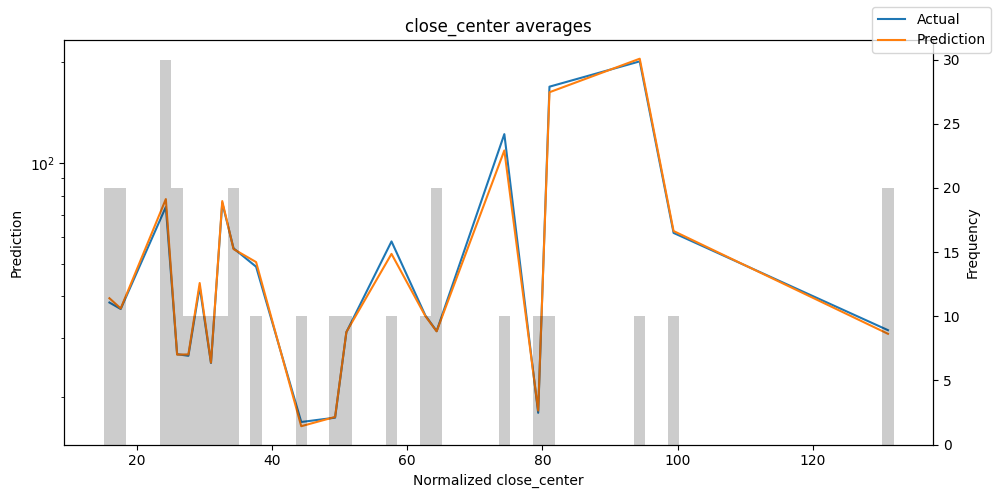

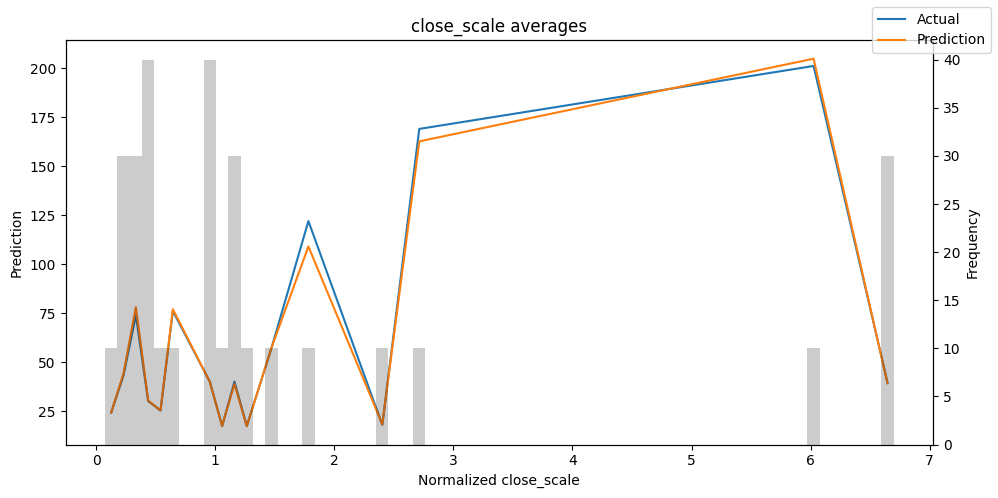

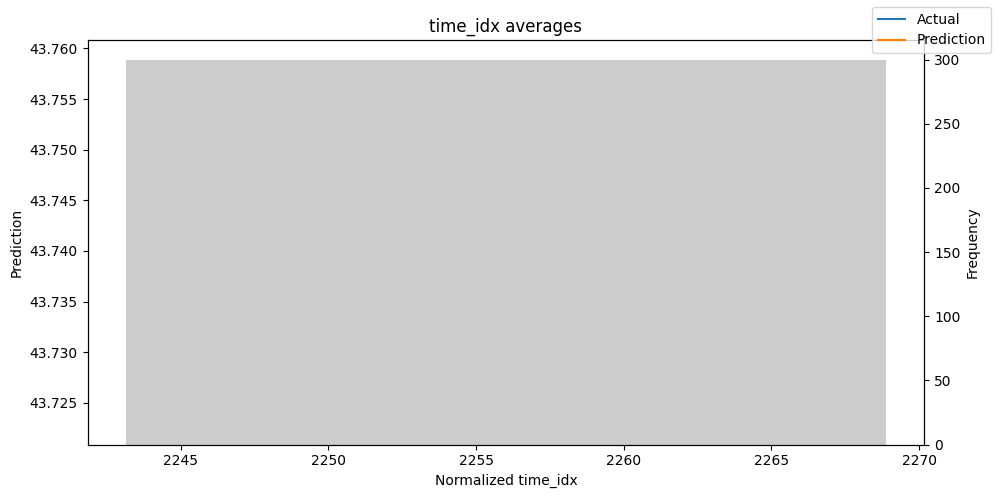

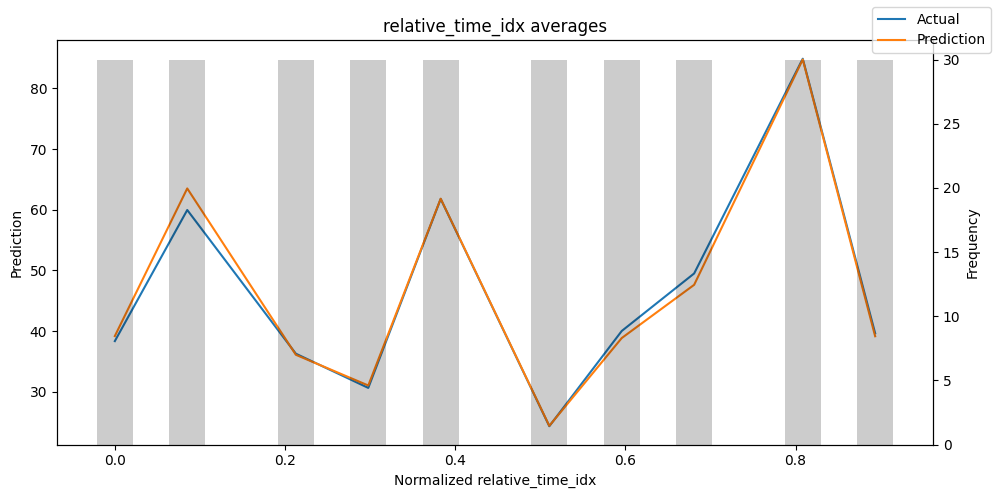

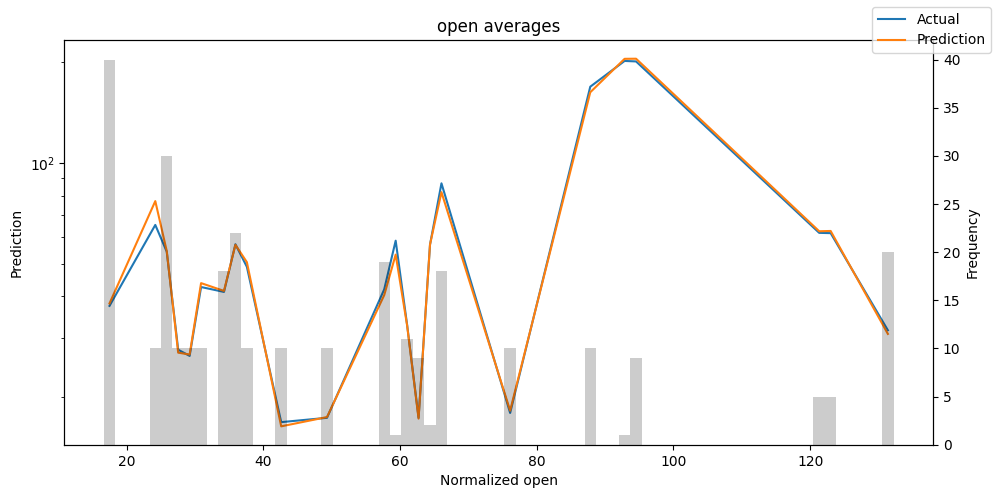

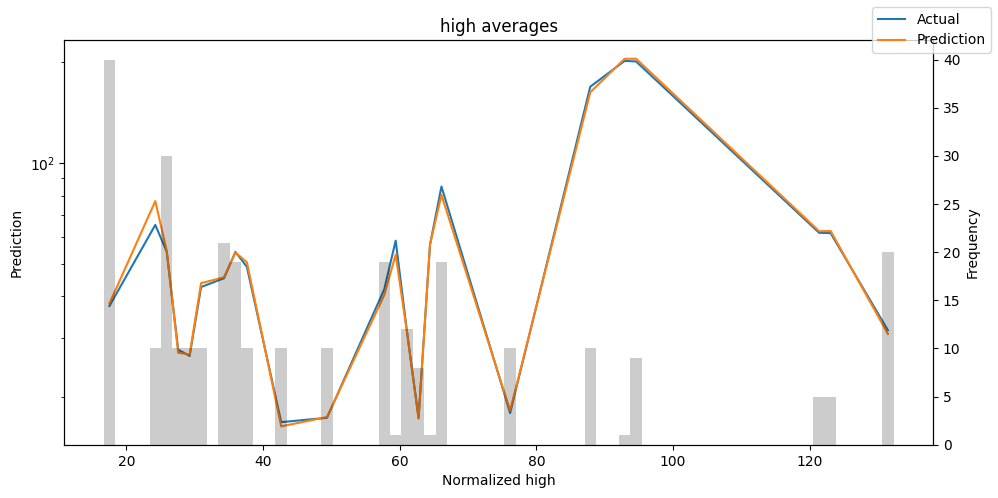

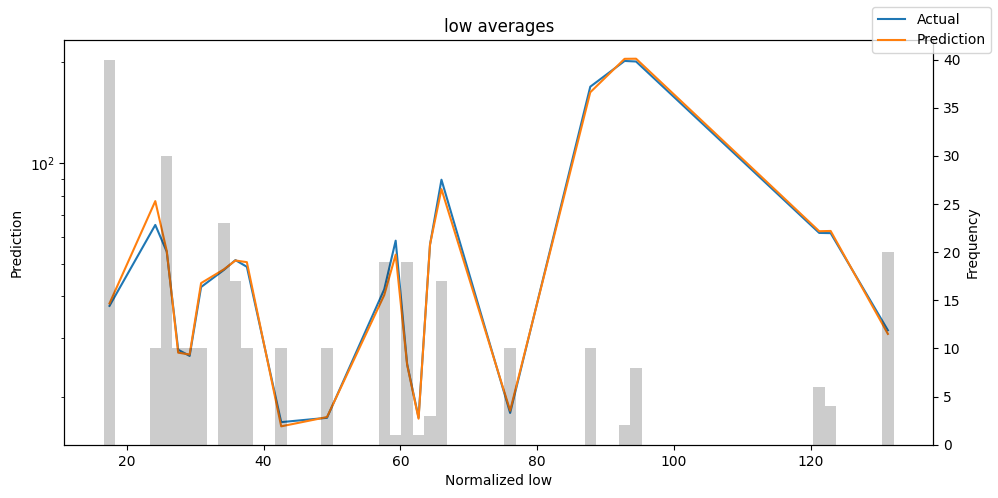

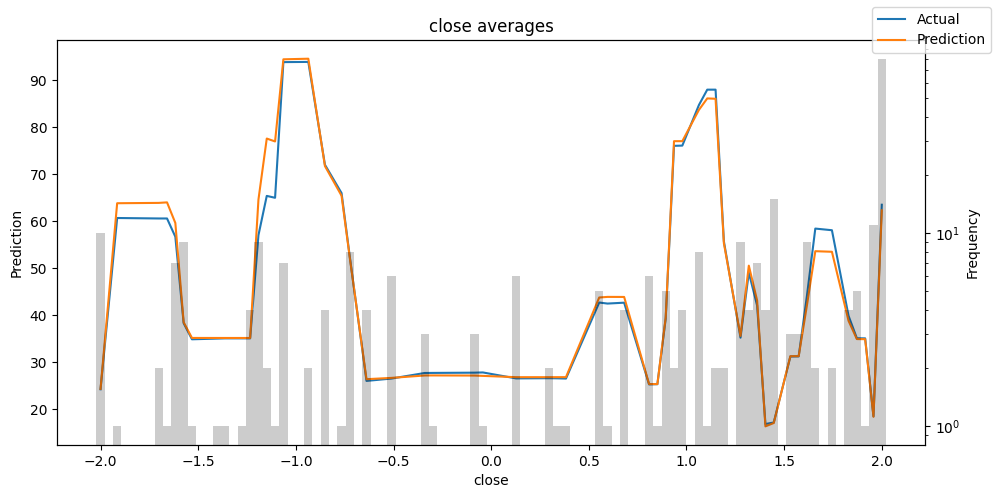

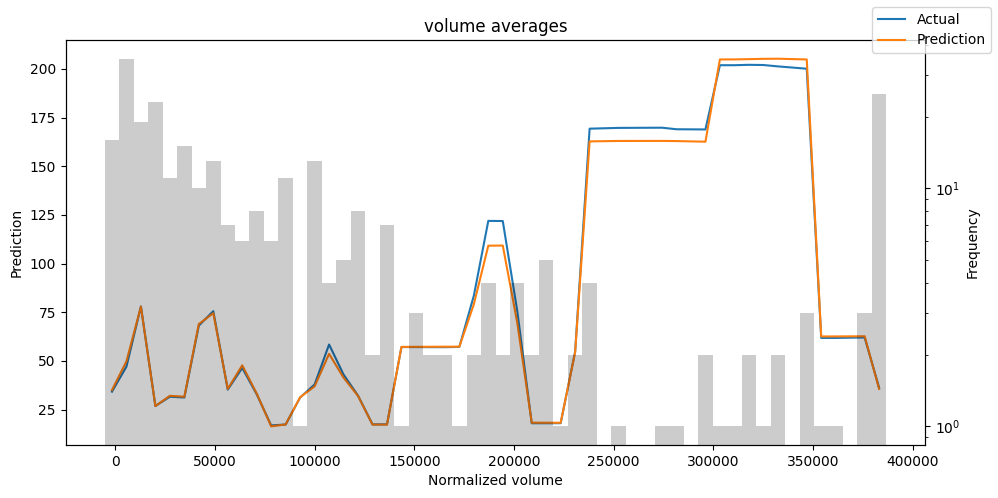

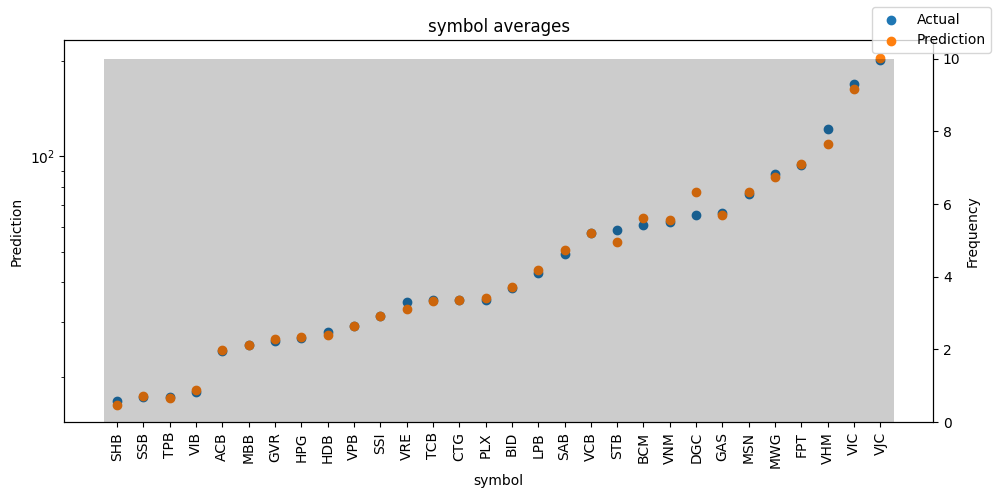

In [76]:
predictions = best_tft.predict(
    val_dataloader, return_x=True, trainer_kwargs=dict(accelerator="cpu")
)
predictions_vs_actuals = best_tft.calculate_prediction_actual_by_variable(
    predictions.x, predictions.output
)
best_tft.plot_prediction_actual_by_variable(predictions_vs_actuals)

In [123]:
df_train[df_train['time_idx']==15]

,time,open,high,low,close,volume,symbol,time_idx
15,2025-12-10 13:10:00,24.20,24.20,24.20,24.20,5000,ACB,15
2746,2025-11-24 13:01:00,66.50,66.60,66.50,66.60,600,BCM,15
5477,2025-12-10 10:30:00,37.55,37.55,37.55,37.55,2900,BID,15
8208,2025-12-10 14:22:00,34.85,34.92,34.78,34.85,40400,CTG,15
10939,2025-12-10 13:13:00,91.59,91.59,91.59,91.59,3800,DGC,15
13670,2025-12-10 14:27:00,95.90,96.00,95.80,95.80,66400,FPT,15
16401,2025-12-09 11:05:00,64.00,64.00,64.00,64.00,500,GAS,15
19132,2025-12-08 11:02:00,27.10,27.10,27.10,27.10,6600,GVR,15
21863,2025-12-10 14:18:00,24.60,24.68,24.60,24.64,85600,HDB,15
24594,2025-12-10 14:27:00,26.75,26.75,26.70,26.70,72500,HPG,15


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, w

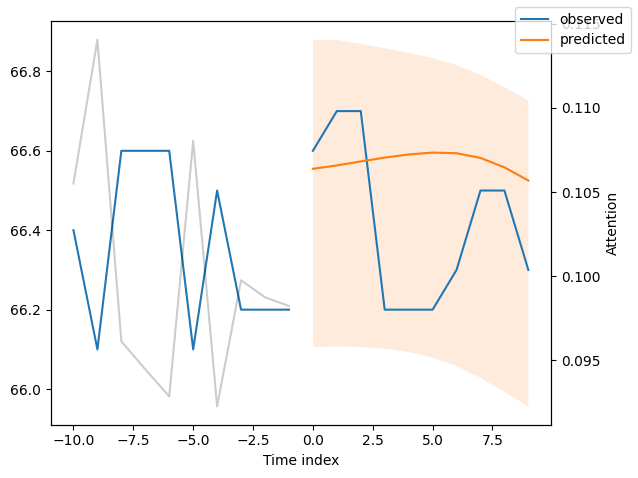

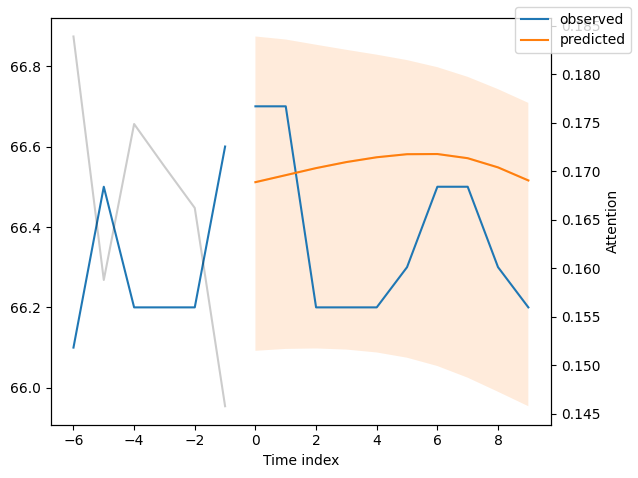

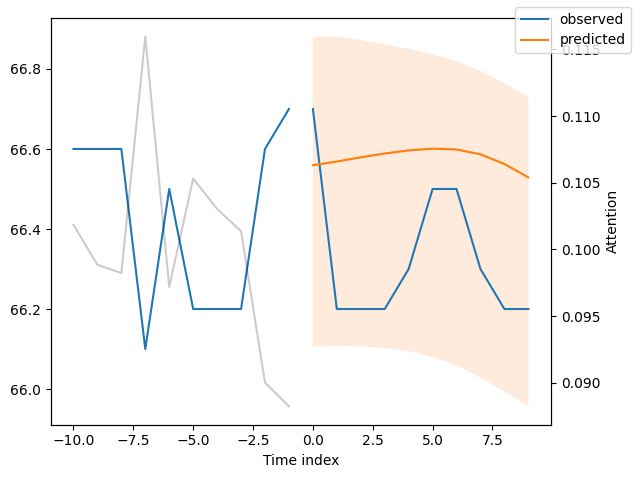

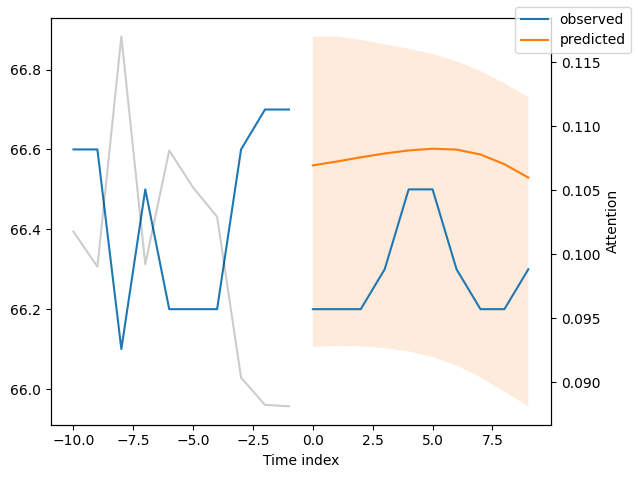

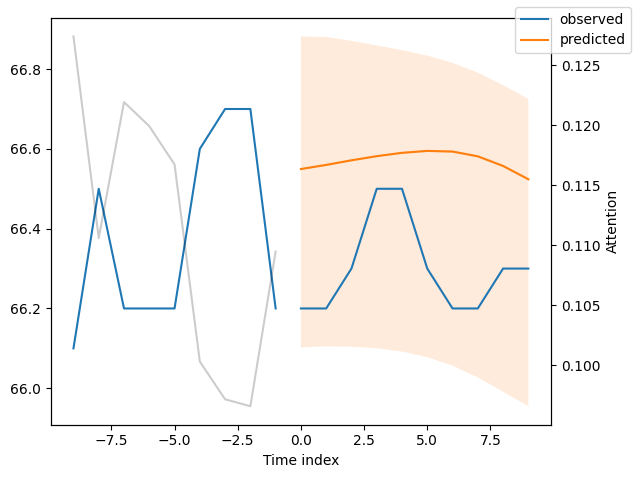

In [133]:
for i in range(15,20):
    raw_prediction = best_tft.predict(
        training.filter(
            lambda x: (x.symbol == "BCM")
            & (x.time_idx_first_prediction == i)
        ),
        mode="raw",
        return_x=True,
        trainer_kwargs=dict(accelerator="cpu"),
    )
    best_tft.plot_prediction(raw_prediction.x, raw_prediction.output, idx=0)

ValueError: After applying filter no sub-sequences left in dataset

In [103]:
training.get_parameters()


{'time_idx': 'time_idx',
 'target': 'close',
 'group_ids': ['symbol'],
 'weight': None,
 'max_encoder_length': 10,
 'min_encoder_length': 5,
 'min_prediction_idx': np.int64(0),
 'min_prediction_length': 1,
 'max_prediction_length': 10,
 'static_categoricals': ['symbol'],
 'static_reals': None,
 'time_varying_known_categoricals': None,
 'time_varying_known_reals': ['time_idx'],
 'time_varying_unknown_categoricals': [],
 'time_varying_unknown_reals': ['open', 'high', 'low', 'close', 'volume'],
 'variable_groups': None,
 'constant_fill_strategy': None,
 'allow_missing_timesteps': False,
 'lags': None,
 'add_relative_time_idx': True,
 'add_target_scales': True,
 'add_encoder_length': False,
 'target_normalizer': GroupNormalizer(
 	method='standard',
 	groups=['symbol'],
 	center=True,
 	scale_by_group=False,
 	transformation='softplus',
 	method_kwargs={}
 ),
 'categorical_encoders': {'__group_id__symbol': NaNLabelEncoder(add_nan=False, warn=True),
  'symbol': NaNLabelEncoder(add_nan=False

In [ ]:
# import pickle

# with open("/content/drive/MyDrive/tft_COPY_newest_1.ckpt",'rb') as f:
#     model=pickle.load(f)

In [56]:
!tensorboard --logdir==lightning_logs

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tensorboard/default.py:30: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
TensorFlow installation not found - running with reduced feature set.
Serving TensorBoard on localhost; to expose to the network, use a proxy or pass --bind_all
TensorBoard 2.20.0 at http://localhost:6006/ (Press CTRL+C to quit)
^C


In [26]:
from pytorch_forecasting import MAPE

test_dataset = TimeSeriesDataSet.from_dataset(training, df_test, predict=True, stop_randomization=True)
test_dataloader = test_dataset.to_dataloader(train=False, batch_size=batch_size, num_workers=0)
predictions = best_tft.predict(test_dataloader, return_y=True, trainer_kwargs=dict(accelerator="mps"))
# print(f"test set MAPE: {MAPE().to("cpu")(predictions.output, predictions.y)}")
# print(f"validation set MAPE: {MAPE()(best_tft.predict(val_dataloader, return_y=True).output, best_tft.predict(val_dataloader, return_y=True).y)}")

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores


In [29]:
predictions_df = pd.DataFrame({
    'symbol': predictions.index['symbol'],     # the symbol column from index_df
    'time_idx': predictions.index['time_idx'],   # the time index column from index_df
    'predictions': list(predictions.output.cpu().numpy())   # store each [10, 3] array as a list in the DataFrame
})

TypeError: 'NoneType' object is not subscriptable

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores


{'attention': <Figure size 640x480 with 1 Axes>,
 'static_variables': <Figure size 700x275 with 1 Axes>,
 'encoder_variables': <Figure size 700x375 with 1 Axes>,
 'decoder_variables': <Figure size 700x250 with 1 Axes>}

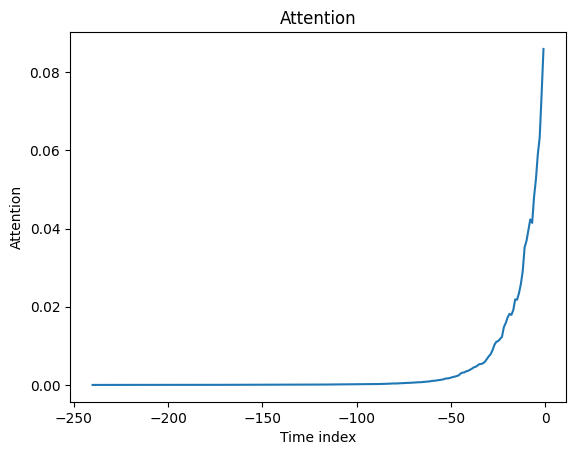

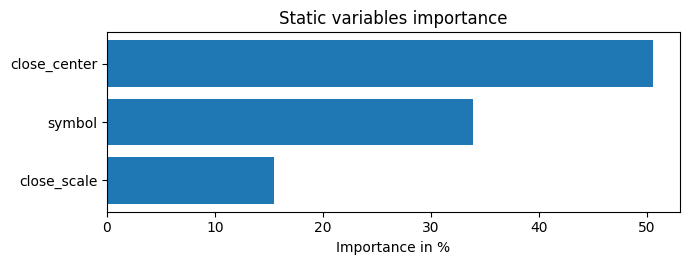

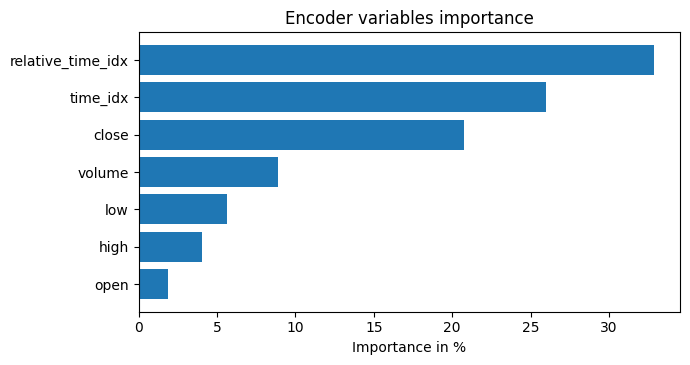

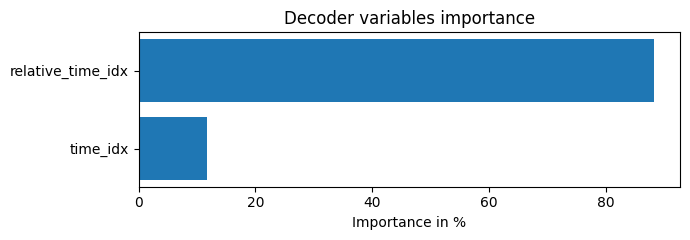

In [17]:
raw_predictions = best_tft.predict(val_dataloader, mode="raw", return_x=True)
interpretation = best_tft.interpret_output(raw_predictions.output, reduction="sum")
best_tft.plot_interpretation(interpretation)

In [20]:
test_dataset = TimeSeriesDataSet.from_dataset(training, df_test.reset_index(), predict=False, stop_randomization=True)
test_dataloader = test_dataset.to_dataloader(train=False, batch_size=batch_size, num_workers=0)

In [24]:
predictions = best_tft.predict(
    test_dataloader,
    mode="quantiles",
    return_index=True,
    trainer_kwargs=dict(accelerator="mps")
)
# #Create DataFrame with predictions
predictions_df = pd.DataFrame({
    'symbol': predictions.index['symbol'],     # the symbol column from index_df
    'time_idx': predictions.index['time_idx'],   # the time index column from index_df
    'predictions': list(predictions.output.cpu().numpy())   # store each [10, 3] array as a list in the DataFrame
})

# # Adjust predictions to match current price levels
# def adjust_predictions(row):
#     if type(row["predictions"]) == float:
#         return row
#     adjust_scale = row["predictions"][0][1] - row["open"]
#     row["predictions"] = row["predictions"] - adjust_scale

#     return row

# # Process predictions
# df_index = df_test.index
# predictions_df = df_test.merge(predictions_df, on=['symbol', 'time_idx'], how='left').set_index(df_index)
# predictions_df = predictions_df.apply(adjust_predictions, axis=1)
# predictions_df = predictions_df[~predictions_df["predictions"].isna()]

# # Calculate predicted and actual changes
# predictions_df["change_prediction_q_50"] = predictions_df["predictions"].apply(lambda x: x[-1][1] - x[0][1])
# predictions_df["change_prediction_q_30"] = predictions_df["predictions"].apply(lambda x: x[-1][0] - x[0][0])
# predictions_df["change_prediction_q_70"] = predictions_df["predictions"].apply(lambda x: x[-1][2] - x[0][2])
# predictions_df["change_actual"] = predictions_df["close"].shift(-10) - predictions_df["open"]
# predictions_df["direction_matches"] = predictions_df.apply(lambda x: np.sign(x["change_prediction_q_50"]) == np.sign(x["change_actual"]), axis=1)
# direction_accuracy = predictions_df["direction_matches"].mean()
# print(f"Directional accuracy: {direction_accuracy}")



💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

In [5]:
from vnstock import Quote
quote = Quote(symbol='ACB', source='VCI')

In [7]:
quote.intraday()

RetryError: RetryError[<Future at 0x11e19c1a0 state=finished raised ValueError>]